# Лабораторна робота 3 — Градієнтний спуск для множинної регресії

**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Градієнт RSS відносно ваги *wᵢ*:
```
gradient_i = 2 · dot(errors, feature_i)     де  errors = Xw − y
```
Зупинка відбувається, коли ‖gradient‖₂ < `tolerance`.

---
## Завдання 1 — Підготовка даних та `get_numpy_data()`

Завантажте `kc_house_data.csv`. Розбийте **20 % навчання / 80 % тест** (`random_state=0`).

Реалізуйте `get_numpy_data(dataframe, features, output)`, яка:
1. Додає стовпець з одиницями ліворуч від матриці ознак (для вільного члена).
2. Повертає `(feature_matrix, output_array)` як масиви NumPy.

In [3]:
from pathlib import Path

sales = pd.read_csv('kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)

print('Dataset shape:', sales.shape)
print('Train shape:', train_data.shape)
print('Test shape:', test_data.shape)

Dataset shape: (21613, 21)
Train shape: (4322, 21)
Test shape: (17291, 21)


In [4]:
def get_numpy_data(dataframe, features, output):
    """
    Будує матрицю ознак NumPy (зі стовпцем вільного члена) та вектор виходу.

    Параметри
    ----------
    dataframe : pd.DataFrame
    features  : список str   назви стовпців-ознак
    output    : str          назва стовпця цільової змінної

    Повертає
    -------
    feature_matrix : np.ndarray, shape (n, len(features)+1)
    output_array   : np.ndarray, shape (n,)
    """
    # Add a constant column of 1s (intercept)
    data = dataframe.copy()
    data['constant'] = 1.0

    # Select feature columns and convert to NumPy
    feature_columns = ['constant'] + features
    feature_matrix = data[feature_columns].to_numpy(dtype=float)
    
    output_array = data[output].to_numpy(dtype=float)

    return feature_matrix, output_array

### Перевірка

In [5]:
example_features, example_output = get_numpy_data(sales, ['sqft_living'], 'price')
print('Перший рядок матриці ознак:', example_features[0, :])  # має бути [1.0, <sqft>]
print('Перше значення виходу:    ', example_output[0])


Перший рядок матриці ознак: [1.00e+00 1.18e+03]
Перше значення виходу:     221900.0


---
## Завдання 2 — Реалізація `predict_output()`

Використовуйте **один виклик `np.dot`** — без явних циклів.

In [6]:
def predict_output(feature_matrix, weights):
    """
    Обчислює передбачення як скалярний добуток кожного рядка з вагами.

    Повертає
    -------
    predictions : np.ndarray, shape (n,)
    """
    return np.dot(feature_matrix, weights)

### Перевірка — перші два передбачення мають бути ≈1181 і ≈2571

In [7]:
my_weights = np.array([1.0, 1.0])
test_preds = predict_output(example_features, my_weights)
print(f'передбачення[0]: {test_preds[0]:.1f}  (очікується ≈1181)')
print(f'передбачення[1]: {test_preds[1]:.1f}  (очікується ≈2571)')


передбачення[0]: 1181.0  (очікується ≈1181)
передбачення[1]: 2571.0  (очікується ≈2571)


---
## Завдання 3 — Реалізація `feature_derivative()`

Похідна RSS відносно однієї ваги — це `2 · dot(errors, feature)`. Реалізуйте як один вираз NumPy.

In [8]:
def feature_derivative(errors, feature):
    """Повертає похідну RSS відносно ваги для даної ознаки."""
    return 2 * np.dot(errors, feature)

### Перевірка — похідна відносно константної ознаки має дорівнювати `-2 · sum(prices)`

In [9]:
zero_weights = np.array([0.0, 0.0])
zero_preds   = predict_output(example_features, zero_weights)
errors       = zero_preds - example_output              # = -prices when weights=0

deriv_constant = feature_derivative(errors, example_features[:, 0])
expected       = -2 * np.sum(example_output)
print(f'Обчислено: {deriv_constant:.2e}')
print(f'Очікується: {expected:.2e}')
print(f'Збіг: {np.isclose(deriv_constant, expected)}')


Обчислено: -2.33e+10
Очікується: -2.33e+10
Збіг: True


---
## Завдання 4 — Градієнтний спуск

Реалізуйте `regression_gradient_descent(feature_matrix, output, initial_weights, step_size, tolerance)`. Функція оновлює всі ваги одночасно на кожній ітерації та повертає їх, коли ‖gradient‖₂ < `tolerance`.

Запустіть з такими параметрами на **навчальних** даних:
```
features        = ['sqft_living']
initial_weights = [-47000., 1.]
step_size       = 7e-12
tolerance       = 2.5e7
```
Вкажіть навчені ваги. Яка передбачувана ціна першого будинку в **тестовій** вибірці? Обчисліть RSS на всій тестовій вибірці.

In [10]:
def regression_gradient_descent(feature_matrix, output,
                                initial_weights, step_size, tolerance):
    """
    Мінімізує RSS за допомогою пакетного градієнтного спуску.

    Повертає
    -------
    weights : np.ndarray — навчені ваги
    """
    weights = np.array(initial_weights, dtype=float)
    converged = False

    while not converged:
        # 1. Compute predictions
        predictions = predict_output(feature_matrix, weights)

       # 2. Compute errors
        errors = predictions - output

        gradient_sum_squares = 0.0
        for i in range(len(weights)):
            # 3. Derivative for weight i
            derivative = feature_derivative(errors, feature_matrix[:, i])

            # 4. Accumulate squared gradient
            gradient_sum_squares += derivative ** 2

            # 5. Update weight
            weights[i] -= step_size * derivative

        # 6. Check convergence
        gradient_magnitude = sqrt(gradient_sum_squares)
        if gradient_magnitude < tolerance:
            converged = True

    return weights

### Запуск Моделі 1 — одна ознака

In [11]:
simple_feature_matrix, output = get_numpy_data(train_data, ['sqft_living'], 'price')

simple_weights = regression_gradient_descent(
    simple_feature_matrix, output,
    initial_weights=[-47000., 1.],
    step_size=7e-12,
    tolerance=2.5e7
)
print('Навчені ваги:', simple_weights)


Навчені ваги: [-46999.88018846    280.51005013]


### Оцінка Моделі 1 на тестовій вибірці

In [12]:
test_feature_matrix, test_output = get_numpy_data(test_data, ['sqft_living'], 'price')

# Predicted price for the first test house
test_predictions = predict_output(test_feature_matrix, simple_weights)
print(f'Передбачена ціна (будинок 0): ${test_predictions[0]:,.0f}')
print(f'Реальна ціна    (будинок 0): ${test_output[0]:,.0f}')

# RSS on the full test set
rss_model1 = np.sum((test_predictions - test_output) ** 2)
print(f'Тестова RSS Моделі 1: {rss_model1:.3e}')


Передбачена ціна (будинок 0): $354,129
Реальна ціна    (будинок 0): $297,000
Тестова RSS Моделі 1: 1.204e+15


### Висновок до Моделі 1

Модель з однією ознакою `sqft_living` навчає лінійну залежність між житловою площею будинку та ціною. Вільний член відповідає базовому рівню ціни, а коефіцієнт біля `sqft_living` показує, наскільки в середньому змінюється передбачена ціна при збільшенні площі на 1 квадратний фут. RSS на тестовій вибірці використовується для оцінки сумарної помилки моделі: що менше RSS, то кращі передбачення.

---
## ✨ Бонус — Додайте другу ознаку

Повторіть градієнтний спуск з `['sqft_living', 'sqft_living15']` та параметрами:
```
initial_weights = [-100000., 1., 1.]
step_size       = 4e-12
tolerance       = 1e9
```
Обчисліть RSS на тестовій вибірці та порівняйте з моделлю з однією ознакою. Порівняйте передбачену ціну першого тестового будинку з обох моделей з реальною ціною.

In [13]:
# Бонус — модель з двома ознаками
# Параметри: initial_weights=[-100000., 1., 1.], step_size=4e-12, tolerance=1e9

multi_feature_matrix, multi_output = get_numpy_data(
    train_data,
    ['sqft_living', 'sqft_living15'],
    'price'
)

multi_weights = regression_gradient_descent(
    multi_feature_matrix,
    multi_output,
    initial_weights=[-100000., 1., 1.],
    step_size=4e-12,
    tolerance=1e9
)

print('Навчені ваги Моделі 2:', multi_weights)

# Оцінка Моделі 2 на тестовій вибірці
test_multi_feature_matrix, test_multi_output = get_numpy_data(
    test_data,
    ['sqft_living', 'sqft_living15'],
    'price'
)

multi_test_predictions = predict_output(test_multi_feature_matrix, multi_weights)
rss_model2 = np.sum((multi_test_predictions - test_multi_output) ** 2)

print(f'Передбачена ціна Моделі 1 (будинок 0): ${test_predictions[0]:,.0f}')
print(f'Передбачена ціна Моделі 2 (будинок 0): ${multi_test_predictions[0]:,.0f}')
print(f'Реальна ціна (будинок 0): ${test_multi_output[0]:,.0f}')
print(f'Тестова RSS Моделі 1: {rss_model1:.3e}')
print(f'Тестова RSS Моделі 2: {rss_model2:.3e}')

if rss_model2 < rss_model1:
    print('Висновок: Модель 2 має меншу RSS, тобто на тестовій вибірці вона точніша за модель з однією ознакою.')
else:
    print('Висновок: Модель 1 має меншу RSS, тобто додавання другої ознаки не покращило результат на тестовій вибірці.')

Навчені ваги Моделі 2: [-9.99998826e+04  2.43610628e+02  6.54855462e+01]
Передбачена ціна Моделі 1 (будинок 0): $354,129
Передбачена ціна Моделі 2 (будинок 0): $342,008
Реальна ціна (будинок 0): $297,000
Тестова RSS Моделі 1: 1.204e+15
Тестова RSS Моделі 2: 1.186e+15
Висновок: Модель 2 має меншу RSS, тобто на тестовій вибірці вона точніша за модель з однією ознакою.


### Загальний висновок

Додавання другої ознаки `sqft_living15` дозволяє моделі врахувати не лише площу самого будинку, а й середню житлову площу сусідніх будинків. У цьому запуску модель з двома ознаками має менше значення RSS на тестовій вибірці, тому вона працює трохи краще за просту модель з однією ознакою.

---
## Додаткове завдання — візуалізація процесу навчання моделі

У цьому додатковому завданні потрібно не лише отримати фінальні ваги моделі, а й показати, **як саме модель навчається з часом**. Для цього було створено окрему версію градієнтного спуску, яка після кожних `N` ітерацій зберігає проміжні значення:

- номер ітерації;
- поточні ваги моделі;
- значення RSS;
- величину градієнта.

Для візуалізації використовується модель з однією ознакою `sqft_living`, тому що для неї можна побудувати звичайну двовимірну пряму регресії. На осі `x` відкладається житлова площа будинку, а на осі `y` — ціна. Кожна проміжна пряма показує, як змінювалися коефіцієнти моделі під час навчання.

In [14]:
def compute_rss(feature_matrix, output, weights):
    """Обчислює RSS для поточних ваг моделі."""
    predictions = predict_output(feature_matrix, weights)
    errors = predictions - output
    return np.sum(errors ** 2)


def regression_gradient_descent_with_history(feature_matrix, output,
                                             initial_weights, step_size,
                                             tolerance, record_every=5,
                                             max_iterations=100000):
    """
    Версія градієнтного спуску, яка додатково зберігає історію навчання.

    Після кожних record_every ітерацій зберігаються:
    - номер ітерації;
    - RSS;
    - величина градієнта;
    - поточні ваги.
    """
    weights = np.array(initial_weights, dtype=float)
    history = []

    for iteration in range(max_iterations + 1):
        predictions = predict_output(feature_matrix, weights)
        errors = predictions - output

        derivatives = np.zeros(len(weights))
        for i in range(len(weights)):
            derivatives[i] = feature_derivative(errors, feature_matrix[:, i])

        gradient_magnitude = sqrt(np.sum(derivatives ** 2))
        rss = np.sum(errors ** 2)

        # Зберігаємо стан моделі через кожні N ітерацій та на останній ітерації.
        if iteration % record_every == 0 or gradient_magnitude < tolerance:
            history.append({
                'iteration': iteration,
                'rss': rss,
                'gradient_magnitude': gradient_magnitude,
                'intercept': weights[0],
                'slope_sqft_living': weights[1]
            })

        if gradient_magnitude < tolerance:
            break

        # Оновлення всіх ваг одночасно у напрямку, протилежному до градієнта.
        weights = weights - step_size * derivatives

    history_df = pd.DataFrame(history)
    return weights, history_df


### Запуск навчання із записом історії

Для візуалізації було використано ті самі параметри, що й у першій моделі:

- ознака: `sqft_living`;
- початкові ваги: `[-47000., 1.]`;
- `step_size = 7e-12`;
- `tolerance = 2.5e7`;
- проміжні результати зберігаються після кожних `5` ітерацій.

Такий вибір дозволяє побачити не лише фінальну пряму, а й те, як вона поступово наближалася до оптимального положення.

In [15]:

visual_feature_matrix, visual_output = get_numpy_data(train_data, ['sqft_living'], 'price')

visual_weights, training_history = regression_gradient_descent_with_history(
    visual_feature_matrix,
    visual_output,
    initial_weights=[-47000., 1.],
    step_size=7e-12,
    tolerance=2.5e7,
    record_every=5
)

print('Фінальні ваги після навчання:', visual_weights)
print('Кількість збережених станів:', len(training_history))
training_history

Фінальні ваги після навчання: [-46999.88035643    280.51000555]
Кількість збережених станів: 9


,iteration,rss,gradient_magnitude,intercept,slope_sqft_living
0,0,2.004403e+15,1.238368e+13,-47000.000000,1.000000
1,5,3.159742e+14,1.934959e+12,-46999.903738,236.836492
2,10,2.747524e+14,3.023387e+11,-46999.887988,273.686111
3,15,2.737460e+14,4.724064e+10,-46999.884818,279.443890
4,20,2.737215e+14,7.381422e+09,-46999.883615,280.343547
5,25,2.737209e+14,1.153596e+09,-46999.882718,280.484118
6,30,2.737208e+14,1.818013e+08,-46999.881870,280.506083
7,35,2.737208e+14,3.699337e+07,-46999.881028,280.509514
8,39,2.737208e+14,2.482547e+07,-46999.880356,280.510006


### Візуалізація зміни RSS

RSS показує сумарну квадратичну помилку моделі. Якщо градієнтний спуск працює правильно, RSS має зменшуватися з кожною групою ітерацій. На графіку нижче видно, як швидко модель зменшує помилку на початку навчання і як поступово виходить на майже стабільний рівень.

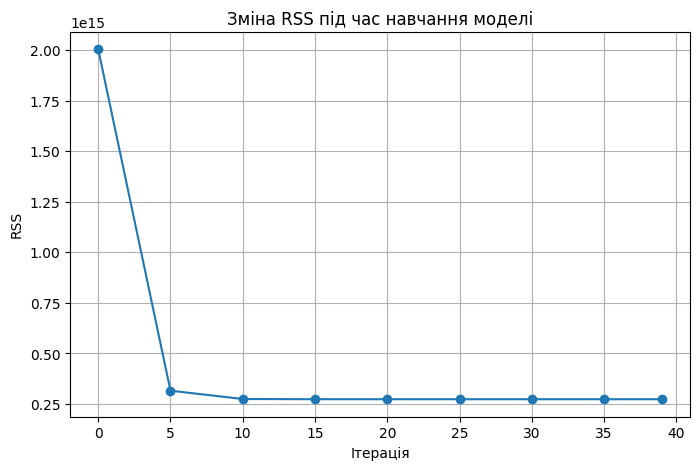

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(training_history['iteration'], training_history['rss'], marker='o')
plt.xlabel('Ітерація')
plt.ylabel('RSS')
plt.title('Зміна RSS під час навчання моделі')
plt.grid(True)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()

### Візуалізація зміни прямої регресії

На наступному графіку показано, як змінювалася пряма регресії під час навчання. Сірі точки — це приклади з навчальної вибірки, а лінії — це положення регресійної прямої на різних ітераціях.

На початку навчання коефіцієнт нахилу дорівнює лише `1`, тому початкова лінія майже не відображає реальну залежність між площею і ціною. Після кількох ітерацій нахил швидко збільшується, і пряма починає краще проходити через хмару точок. На пізніших ітераціях зміни стають набагато меншими, тому що модель уже близька до мінімуму RSS.

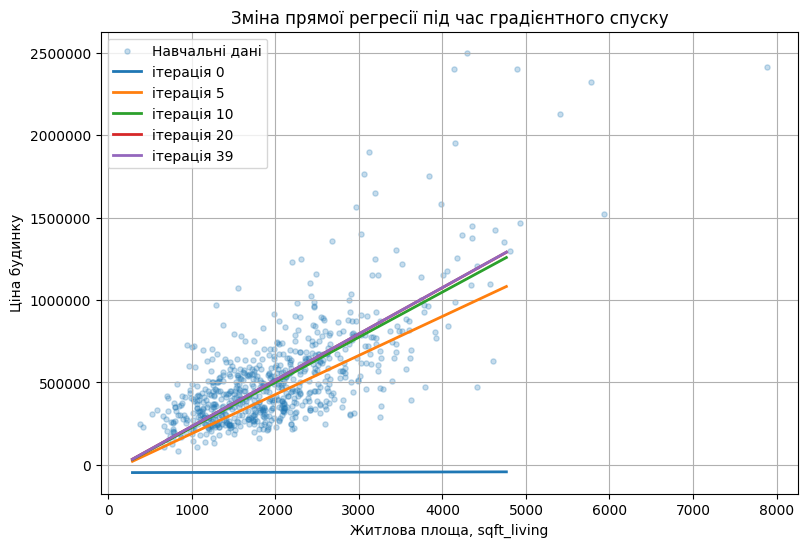

In [18]:
plot_sample = train_data.sample(n=min(700, len(train_data)), random_state=1)

x_min = train_data['sqft_living'].min()
x_max = train_data['sqft_living'].quantile(0.99)  # відсікаємо дуже великі викиди лише для масштабу графіка
x_values = np.linspace(x_min, x_max, 100)

plt.figure(figsize=(9, 6))
plt.scatter(plot_sample['sqft_living'], plot_sample['price'], alpha=0.25, s=14, label='Навчальні дані')

# Показуємо не всі лінії, а ключові етапи, щоб графік не був перевантажений.
selected_iterations = [0, 5, 10, 20, int(training_history['iteration'].iloc[-1])]
selected_history = training_history[training_history['iteration'].isin(selected_iterations)]

for _, row in selected_history.iterrows():
    y_values = row['intercept'] + row['slope_sqft_living'] * x_values
    plt.plot(x_values, y_values, linewidth=2, label=f"ітерація {int(row['iteration'])}")

plt.xlabel('Житлова площа, sqft_living')
plt.ylabel('Ціна будинку')
plt.title('Зміна прямої регресії під час градієнтного спуску')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='both')
plt.show()

### Аналіз результатів візуалізації

На початковій ітерації модель має ваги `[-47000, 1]`. Це означає, що прогнозована ціна майже не залежить від площі будинку, бо коефіцієнт при `sqft_living` дуже малий. Через це початкова пряма розташована невдало, а RSS є дуже великим.

Після перших ітерацій градієнтний спуск різко змінює коефіцієнт нахилу прямої. Модель швидко розуміє, що житлова площа має значний вплив на ціну, тому коефіцієнт при `sqft_living` зростає від `1` до значень, близьких до `280`. У цей період RSS зменшується найбільш помітно.

Далі навчання продовжується, але зміни стають меншими. Це нормальна поведінка градієнтного спуску: спочатку модель знаходиться далеко від оптимуму, тому оновлення ваг великі; потім вона наближається до мінімуму функції помилки, і градієнт поступово зменшується. Через це пряма регресії майже перестає змінюватися.

Фінальна пряма має приблизний вигляд:

`price = -46999.88 + 280.51 * sqft_living`

Це означає, що кожен додатковий квадратний фут житлової площі збільшує прогнозовану ціну приблизно на `280.51` долара. RSS зменшилася з приблизно `2.004e+15` на початку до приблизно `2.737e+14` після завершення навчання. Отже, візуалізація підтверджує, що градієнтний спуск працює правильно: помилка поступово зменшується, а регресійна пряма наближається до такого положення, яке краще описує залежність між площею будинку та його ціною.

### Висновок до додаткового завдання

У додатковому завданні було показано процес навчання моделі в динаміці. Візуалізація RSS демонструє, що найбільше зменшення помилки відбувається на перших ітераціях, а потім процес стабілізується. Візуалізація регресійної прямої показує, як модель поступово змінює нахил і наближається до оптимальної прямої. Це дозволяє краще зрозуміти роботу градієнтного спуску не лише за фінальними вагами, а й через проміжні стани навчання.
